# Capstone Project: Analisis Dataset Lowongan Kerja

Notebook ini disusun sebagai bagian dari proyek capstone untuk menganalisis dataset lowongan kerja dari beberapa sumber. Analisis dilakukan melalui tahapan data collection, assessing data, preprocessing, exploratory data analysis (EDA), explanatory analysis, serta analisis fitur berbasis teks.

## Tujuan Proyek
Tujuan dari analisis ini adalah:
1. Menggabungkan dan menstandarkan dataset lowongan kerja dari beberapa sumber.
2. Membersihkan dan mempersiapkan data agar siap dianalisis.
3. Mengidentifikasi pola distribusi job title, kategori pekerjaan, dan skill yang paling sering muncul.
4. Menganalisis karakteristik job description, termasuk panjang deskripsi, kata kunci dominan, dan kualitas informasi teks.
5. Menemukan insight yang dapat digunakan sebagai dasar pada tahap feature engineering atau pengembangan sistem berbasis data lowongan kerja.

## Alur Analisis
Tahapan yang dilakukan dalam notebook ini meliputi:
- Data Collection dan Assessing Data
- Data Cleaning dan Preprocessing
- Exploratory Data Analysis (EDA)
- Explanatory Data Analysis
- Analisis Tambahan pada Job Description

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

from collections import Counter
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Dataset

In [ ]:
path1 = '/content/drive/MyDrive/Project_DS/data/job_postings.csv'
path2 = '/content/drive/MyDrive/Project_DS/data/jobstreet_all_job_dataset.csv'

In [ ]:
df1 = pd.read_csv(path1, low_memory=False)
df2 = pd.read_csv(path2, low_memory=False)

## Data Collection dan Pemeriksaan Awal

In [ ]:
print("Shape df1:", df1.shape)
print("Shape df2:", df2.shape)

Shape df1: (15886, 27)
Shape df2: (69024, 11)


In [ ]:
df1.head()

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,NaN,45760.0,YEARLY,Full-time,"Chico, CA",...,1.710000e+12,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,USD,BASE_SALARY
1,133114754,77766802.0,Sales Manager,Are you a dynamic and creative marketing profe...,NaN,NaN,NaN,NaN,Full-time,"Santa Clarita, CA",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN
2,133196985,1089558.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,NaN,NaN,NaN,NaN,Contract,"New York, NY",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,CONTRACT,NaN,NaN
3,381055942,96654609.0,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,NaN,NaN,NaN,NaN,Full-time,"Forney, TX",...,1.700000e+12,NaN,NaN,NaN,1.690000e+12,NaN,0,FULL_TIME,NaN,NaN
4,529257371,1244539.0,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,NaN,NaN,NaN,NaN,Full-time,"New York, NY",...,1.710000e+12,NaN,NaN,NaN,1.690000e+12,NaN,1,FULL_TIME,NaN,NaN


In [ ]:
df2.head()

,job_id,job_title,company,descriptions,location,category,subcategory,role,type,salary,listingDate
0,74630583.0,Procurement Executive (Contract),Coca-Cola Bottlers (Malaysia) Sdn Bhd,Position Purpose\nManage aspects of procuremen...,Negeri Sembilan,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",procurement-executive,Contract/Temp,NaN,2024-03-21T05:58:35Z
1,74660602.0,Account Executive/ Assistant,Acoustic & Lighting System Sdn Bhd,We are looking for a Account Executive/ Assist...,Petaling,Accounting,Bookkeeping & Small Practice Accounting,executive-assistant,Full time,"RM 2,800 – RM 3,200 per month",2024-03-22T06:52:57Z
2,74655679.0,"Data Analyst - Asset Management, SPX Express",Shopee Mobile Malaysia Sdn Bhd,Performs detailed data analysis on existing sp...,Klang District,"Manufacturing, Transport & Logistics",Analysis & Reporting,asset-management-analyst,Full time,NaN,2024-03-22T04:22:43Z
3,74657624.0,Service Engineer,Sun Medical Systems Sdn Bhd,"You are important for troubleshooting, install...",Petaling,Engineering,Electrical/Electronic Engineering,services-engineer,Full time,"RM 3,000 – RM 3,500 per month",2024-03-22T05:32:09Z
4,74679363.0,Purchasing Executive,Magnet Security & Automation Sdn. Bhd.,"MAG is a trailblazer in the industry, boasting...",Hulu Langat,"Manufacturing, Transport & Logistics","Purchasing, Procurement & Inventory",purchasing-executive,Full time,"RM 2,800 – RM 3,500 per month",2024-03-23T03:56:39Z


In [ ]:
print("Kolom df1:")
print(df1.columns)

print("\nKolom df2:")
print(df2.columns)

Kolom df1:
Index(['job_id', 'company_id', 'title', 'description', 'max_salary',
       'med_salary', 'min_salary', 'pay_period', 'formatted_work_type',
       'location', 'applies', 'original_listed_time', 'remote_allowed',
       'views', 'job_posting_url', 'application_url', 'application_type',
       'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc',
       'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type'],
      dtype='object')

Kolom df2:
Index(['job_id', 'job_title', 'company', 'descriptions', 'location',
       'category', 'subcategory', 'role', 'type', 'salary', 'listingDate'],
      dtype='object')


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15886 entries, 0 to 15885
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      15886 non-null  int64  
 1   company_id                  15520 non-null  float64
 2   title                       15886 non-null  object 
 3   description                 15885 non-null  object 
 4   max_salary                  5521 non-null   float64
 5   med_salary                  981 non-null    float64
 6   min_salary                  5521 non-null   float64
 7   pay_period                  6502 non-null   object 
 8   formatted_work_type         15886 non-null  object 
 9   location                    15886 non-null  object 
 10  applies                     8700 non-null   float64
 11  original_listed_time        15886 non-null  float64
 12  remote_allowed              2340 non-null   float64
 13  views                       131

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69024 entries, 0 to 69023
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_id        69024 non-null  float64
 1   job_title     69024 non-null  object 
 2   company       69024 non-null  object 
 3   descriptions  69024 non-null  object 
 4   location      69024 non-null  object 
 5   category      69024 non-null  object 
 6   subcategory   69024 non-null  object 
 7   role          66772 non-null  object 
 8   type          69024 non-null  object 
 9   salary        31594 non-null  object 
 10  listingDate   69024 non-null  object 
dtypes: float64(1), object(10)
memory usage: 5.8+ MB


## Assessing Data

In [ ]:
df1.isnull().sum()

,0
job_id,0
company_id,366
title,0
description,1
max_salary,10365
med_salary,14905
min_salary,10365
pay_period,9384
formatted_work_type,0
location,0


In [ ]:
df2.isnull().sum()

,0
job_id,0
job_title,0
company,0
descriptions,0
location,0
category,0
subcategory,0
role,2252
type,0
salary,37430


## Standarisasi Struktur Kolom

In [ ]:
df1 = df1.rename(columns={
    "title": "job_title",
    "description": "description",
    "skills_desc": "skills"
})

df2 = df2.rename(columns={
    "descriptions": "description",
    "job_title": "job_title"
})

In [ ]:
possible_cols = ["category", "subcategory", "role"]

for col in possible_cols:
    if col not in df2.columns:
        df2[col] = ""

if "skills" not in df2.columns:
    df2["skills"] = (
        df2["category"].fillna("").astype(str) + ", " +
        df2["subcategory"].fillna("").astype(str) + ", " +
        df2["role"].fillna("").astype(str)
    ).str.strip(", ").str.strip()

In [ ]:
required_cols = ["job_id", "job_title", "description", "location", "skills"]

for col in required_cols:
    if col not in df1.columns:
        df1[col] = np.nan
    if col not in df2.columns:
        df2[col] = np.nan

## Pemilihan Kolom Penting

In [ ]:
common_cols = ["job_id", "job_title", "description", "location", "skills"]

df1_clean = df1[common_cols].copy()
df2_clean = df2[common_cols].copy()

In [ ]:
df1_clean.head()

,job_id,job_title,description,location,skills
0,85008768,Licensed Insurance Agent,While many industries were hurt by the last fe...,"Chico, CA",NaN
1,133114754,Sales Manager,Are you a dynamic and creative marketing profe...,"Santa Clarita, CA",NaN
2,133196985,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,"New York, NY",NaN
3,381055942,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,"Forney, TX",NaN
4,529257371,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,"New York, NY",NaN


In [ ]:
df2_clean.head()

,job_id,job_title,description,location,skills
0,74630583.0,Procurement Executive (Contract),Position Purpose\nManage aspects of procuremen...,Negeri Sembilan,"Manufacturing, Transport & Logistics, Purchasi..."
1,74660602.0,Account Executive/ Assistant,We are looking for a Account Executive/ Assist...,Petaling,"Accounting, Bookkeeping & Small Practice Accou..."
2,74655679.0,"Data Analyst - Asset Management, SPX Express",Performs detailed data analysis on existing sp...,Klang District,"Manufacturing, Transport & Logistics, Analysis..."
3,74657624.0,Service Engineer,"You are important for troubleshooting, install...",Petaling,"Engineering, Electrical/Electronic Engineering..."
4,74679363.0,Purchasing Executive,"MAG is a trailblazer in the industry, boasting...",Hulu Langat,"Manufacturing, Transport & Logistics, Purchasi..."


## Penggabungan Dataset

In [ ]:
df = pd.concat([df1_clean, df2_clean], ignore_index=True)
print("Shape dataframe gabungan:", df.shape)

Shape dataframe gabungan: (84910, 5)


In [ ]:
df.head()

,job_id,job_title,description,location,skills
0,85008768.0,Licensed Insurance Agent,While many industries were hurt by the last fe...,"Chico, CA",NaN
1,133114754.0,Sales Manager,Are you a dynamic and creative marketing profe...,"Santa Clarita, CA",NaN
2,133196985.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,"New York, NY",NaN
3,381055942.0,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,"Forney, TX",NaN
4,529257371.0,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,"New York, NY",NaN


## Data Cleaning

In [ ]:
df = df.drop_duplicates()
print("Shape setelah menghapus duplikat:", df.shape)

Shape setelah menghapus duplikat: (84910, 5)


In [ ]:
df["job_title"] = df["job_title"].fillna("unknown")
df["description"] = df["description"].fillna("")
df["location"] = df["location"].fillna("unknown")
df["skills"] = df["skills"].fillna("")

In [ ]:
df.isnull().sum()

,0
job_id,0
job_title,0
description,0
location,0
skills,0


## Text Preprocessing

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = text.replace("\\n", " ")
    text = re.sub(r"[^a-z0-9\s,]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
df["description_clean"] = df["description"].apply(clean_text)
df["skills_clean"] = df["skills"].apply(clean_text)

In [ ]:
df["desc_tokens"] = df["description_clean"].apply(lambda x: x.split())
df["skills_list"] = df["skills_clean"].apply(
    lambda x: [i.strip() for i in x.split(",") if i.strip() != ""]
)

In [ ]:
df[df["skills"] != ""][["job_title", "skills", "skills_clean", "skills_list"]].head(10)

,job_title,skills,skills_clean,skills_list
520,Special Education Teacher,EducationBachelors or better in Education or r...,educationbachelors or better in education or r...,[educationbachelors or better in education or ...
528,SAP Tester,\n\nMinimum Requirements Required Knowledge an...,minimum requirements required knowledge and ex...,[minimum requirements required knowledge and e...
643,Principal Scientist,EducationDoctorate or better.,educationdoctorate or better,[educationdoctorate or better]
898,Engineering Manager - Santa Ana,\n\nMust Have: Minimum Requirements \n\nTo be ...,must have minimum requirements to be considere...,[must have minimum requirements to be consider...
911,Game/ Server Engineer,"C++,Networking,Gaming,MMO","c ,networking,gaming,mmo","[c, networking, gaming, mmo]"
1020,Jr. Financial Analyst,\n\nIdeal Candidate Profile – “Our Casting Cal...,ideal candidate profile our casting call team ...,[ideal candidate profile our casting call team...
1163,Operations Specialist - Up to $60K,"Operations, Specialist, Client, Services, Acco...","operations, specialist, client, services, acco...","[operations, specialist, client, services, acc..."
1487,Board Certified Behavior Analyst (BCBA) → $200...,EducationMasters or better in Behavioral Scien...,educationmasters or better in behavioral scien...,[educationmasters or better in behavioral scie...
1667,Special Education Teacher → $2500 Sign-on Bonus!,EducationBachelors or better in Education or r...,educationbachelors or better in education or r...,[educationbachelors or better in education or ...
2036,Special Education Teacher → $2500 Sign-on Bonus!!,EducationBachelors or better in Education or r...,educationbachelors or better in education or r...,[educationbachelors or better in education or ...


## Exploratory Data Analysis: Distribusi Job Title

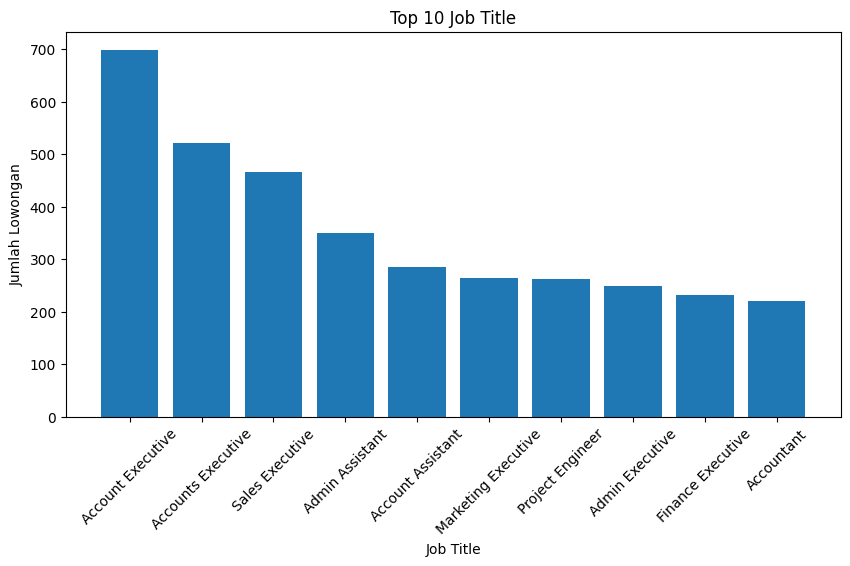

In [ ]:
job_counts = df["job_title"].value_counts().head(10)
job_counts

plt.figure(figsize=(10,5))
plt.bar(job_counts.index, job_counts.values)
plt.title("Top 10 Job Title")
plt.xlabel("Job Title")
plt.ylabel("Jumlah Lowongan")
plt.xticks(rotation=45)
plt.show()

## Distribusi Kategori Pekerjaan

,count
category,
Call Centre & Customer Service,1792
Banking & Financial Services,2641
Marketing & Communications,3004
Human Resources & Recruitment,4055
"Manufacturing, Transport & Logistics",5388
Sales,5715
Administration & Office Support,7101
Information & Communication Technology,8675
Engineering,8978


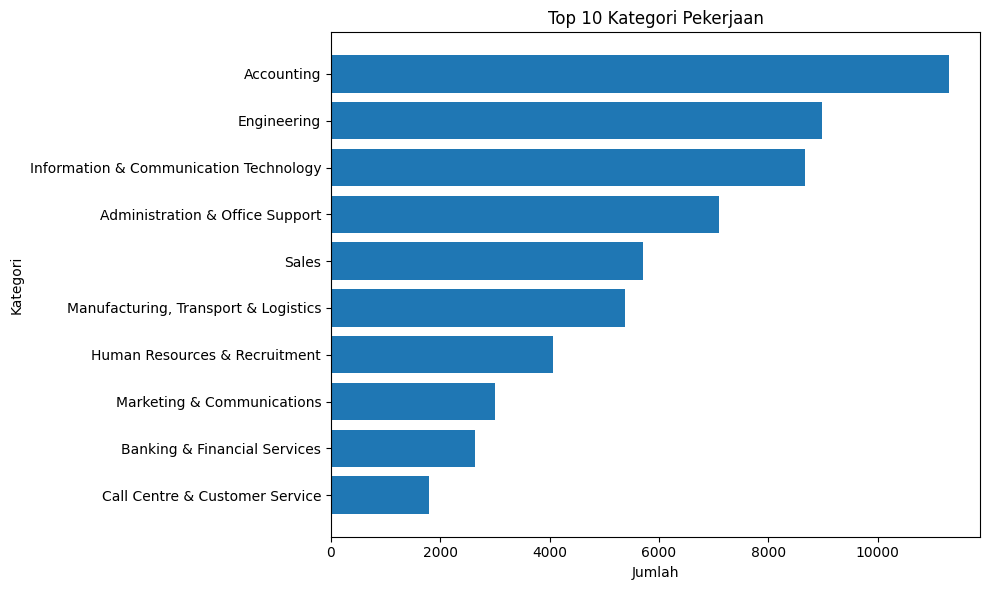

In [ ]:
if "category" in df2.columns:
    category_counts = (
        df2["category"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .replace("", "unknown")
        .value_counts()
        .head(10)
        .sort_values(ascending=True)
    )

    display(category_counts)

    plt.figure(figsize=(10,6))
    plt.barh(category_counts.index, category_counts.values)
    plt.title("Top 10 Kategori Pekerjaan")
    plt.xlabel("Jumlah")
    plt.ylabel("Kategori")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'category' tidak tersedia, sehingga analisis distribusi kategori dilewati.")

## Frekuensi Skill yang Paling Sering Muncul

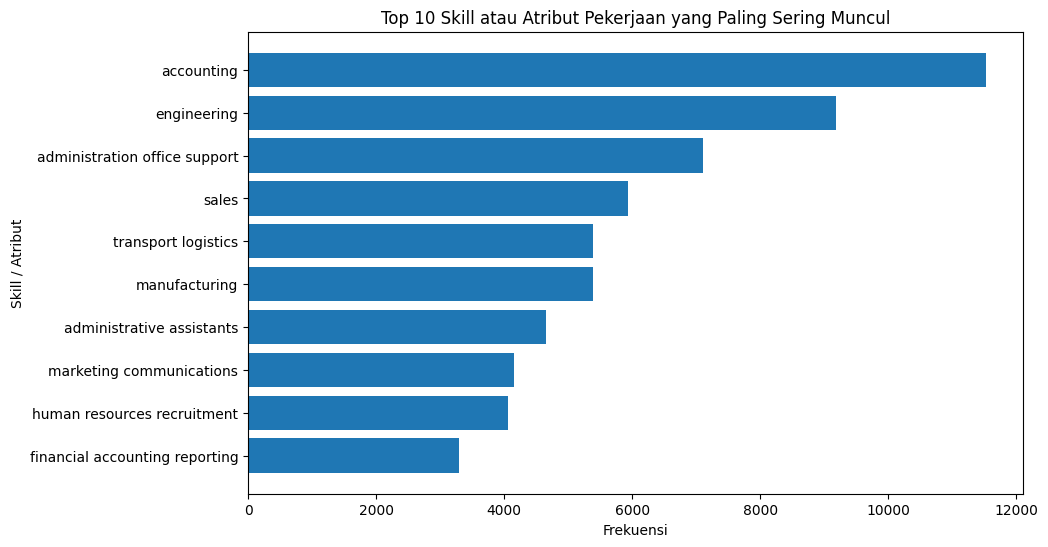

In [ ]:
from collections import Counter

all_skills = []
for row in df["skills_list"]:
    all_skills.extend(row)

filtered_skills = [
    s for s in all_skills
    if s != ""
    and len(s.split()) <= 4
    and len(s) <= 30
]

skill_counts = Counter(filtered_skills)

top_skills = pd.DataFrame(skill_counts.items(), columns=["skill", "count"])
top_skills = top_skills.sort_values(by="count", ascending=False).head(10)
top_skills = top_skills.sort_values(by="count", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(top_skills["skill"], top_skills["count"])
plt.title("Top 10 Skill atau Atribut Pekerjaan yang Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.ylabel("Skill / Atribut")
plt.show()

## Distribusi Jumlah Skill per Lowongan

In [ ]:
df["skill_count"] = df["skills_list"].apply(len)
df["skill_count"].describe()

,skill_count
count,84910.000000
mean,2.555871
std,1.387251
min,0.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,48.000000


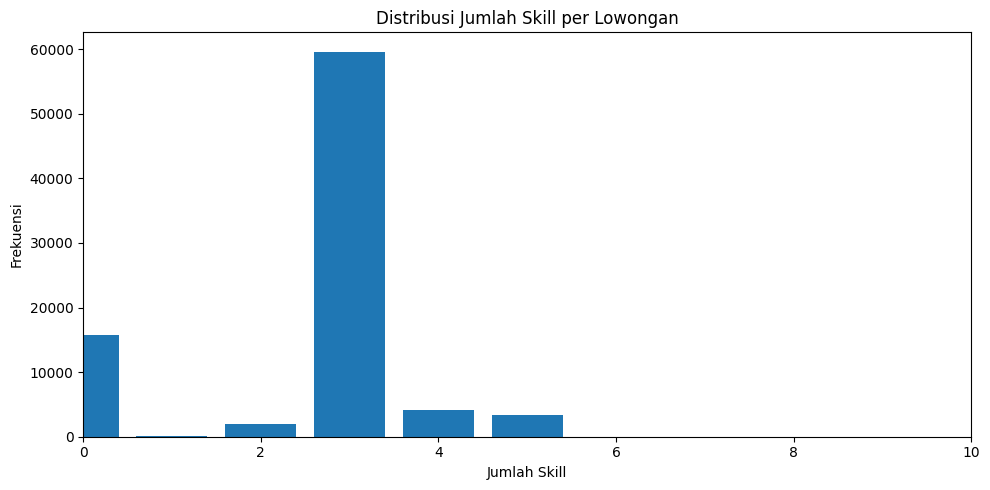

In [ ]:
skill_count_dist = df["skill_count"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(skill_count_dist.index, skill_count_dist.values)
plt.title("Distribusi Jumlah Skill per Lowongan")
plt.xlabel("Jumlah Skill")
plt.ylabel("Frekuensi")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

## Missing Value dan Karakteristik Dataset


In [ ]:
missing = df.isnull().sum().reset_index()
missing.columns = ["column", "missing_count"]
missing["missing_pct"] = (missing["missing_count"] / len(df)) * 100
missing

,column,missing_count,missing_pct
0,job_id,0,0.0
1,job_title,0,0.0
2,description,0,0.0
3,location,0,0.0
4,skills,0,0.0
5,description_clean,0,0.0
6,skills_clean,0,0.0
7,desc_tokens,0,0.0
8,skills_list,0,0.0
9,skill_count,0,0.0


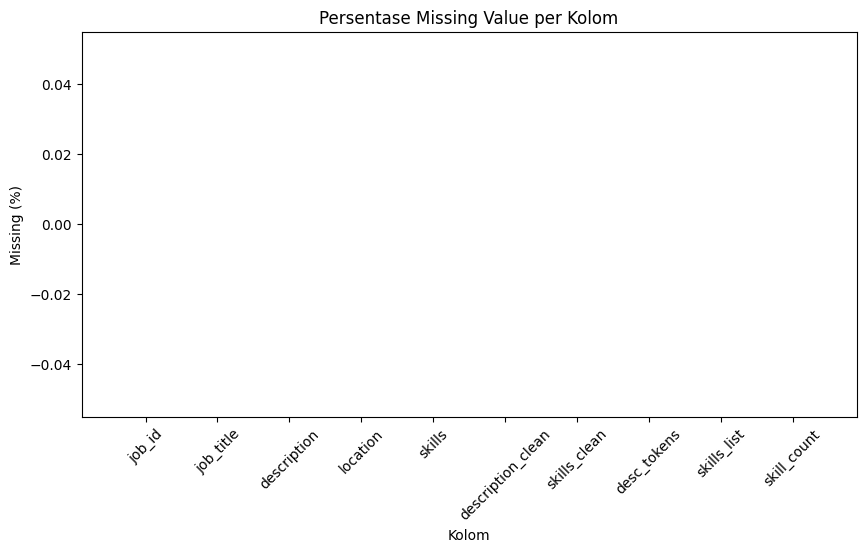

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(missing["column"], missing["missing_pct"])
plt.title("Persentase Missing Value per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45)
plt.show()

## Analisis Co-occurrence Skill

In [ ]:
pair_counter = Counter()

for skills in df["skills_list"]:
    unique_skills = list(set(skills))
    for pair in combinations(sorted(unique_skills), 2):
        pair_counter[pair] += 1

top_pairs = pd.DataFrame(pair_counter.items(), columns=["pair", "count"])
top_pairs = top_pairs.sort_values(by="count", ascending=False).head(10)

top_pairs

,pair,count
10093,"(manufacturing, transport logistics)",5388
10125,"(administration office support, administrative...",4655
10100,"(accounting, bookkeeping small practice accoun...",3845
10116,"(accounting, financial accounting reporting)",3292
10141,"(consulting generalist hr, human resources rec...",2398
10108,"(electrical electronic engineering, engineering)",2348
10149,"(account relationship management, sales)",2092
10097,"(procurement inventory, purchasing)",1979
10091,"(manufacturing, procurement inventory)",1979
10098,"(procurement inventory, transport logistics)",1979


In [ ]:
top_pairs["pair_str"] = top_pairs["pair"].apply(lambda x: f"{x[0]} - {x[1]}")

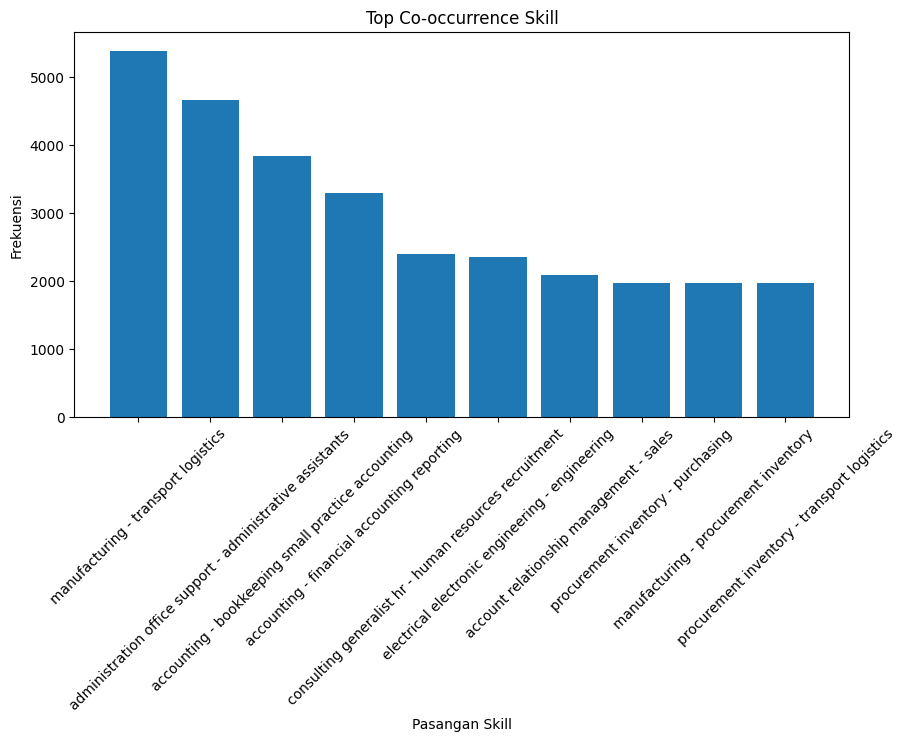

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(top_pairs["pair_str"], top_pairs["count"])
plt.title("Top Co-occurrence Skill")
plt.xlabel("Pasangan Skill")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

## Analisis Panjang Job Description

In [ ]:
df["desc_word_count"] = df["description_clean"].apply(lambda x: len(x.split()))
df[["description_clean", "desc_word_count"]].head()

,description_clean,desc_word_count
0,while many industries were hurt by the last fe...,298
1,are you a dynamic and creative marketing profe...,404
2,join us as a model risk auditor showcase your ...,283
3,business managerfirst baptist church forneyfor...,302
4,you could be one of the magic makers ken fulk ...,279


In [ ]:
df["desc_word_count"].describe()

,desc_word_count
count,84910.000000
mean,354.642975
std,258.679357
min,0.000000
25%,174.000000
50%,277.000000
75%,465.000000
max,2993.000000


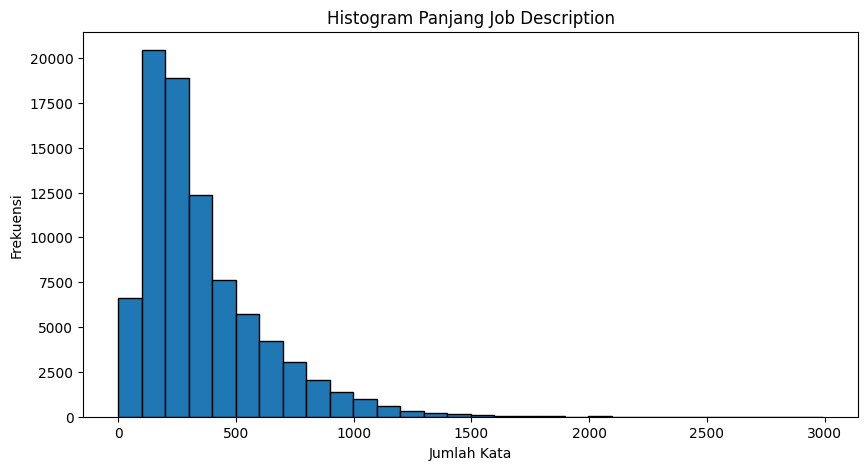

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df["desc_word_count"], bins=30, edgecolor="black")
plt.title("Histogram Panjang Job Description")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

### Interpretasi
Histogram digunakan untuk melihat distribusi panjang job description secara umum, sedangkan boxplot digunakan untuk mendeteksi penyebaran data dan outlier. Jika terdapat beberapa nilai yang jauh lebih besar dari mayoritas data, maka dapat disimpulkan bahwa ada lowongan dengan deskripsi yang sangat panjang dibandingkan lowongan lainnya.

## Analisis Kata Kunci Dominan per Job Title

Untuk memahami karakteristik masing-masing posisi pekerjaan, dilakukan analisis kata kunci dominan pada job description berdasarkan job title. Analisis ini menggunakan dua pendekatan:
1. **Word Cloud**, untuk melihat kata yang paling sering muncul secara visual
2. **TF-IDF**, untuk mengidentifikasi kata yang paling penting dalam kumpulan deskripsi tertentu

Agar analisis tetap fokus, digunakan beberapa job title yang paling sering muncul.

In [ ]:
top_titles = df["job_title"].value_counts().head(3).index.tolist()
top_titles

['Account Executive', 'Accounts Executive', 'Sales Executive']

Job Title: Account Executive
Jumlah data: 698


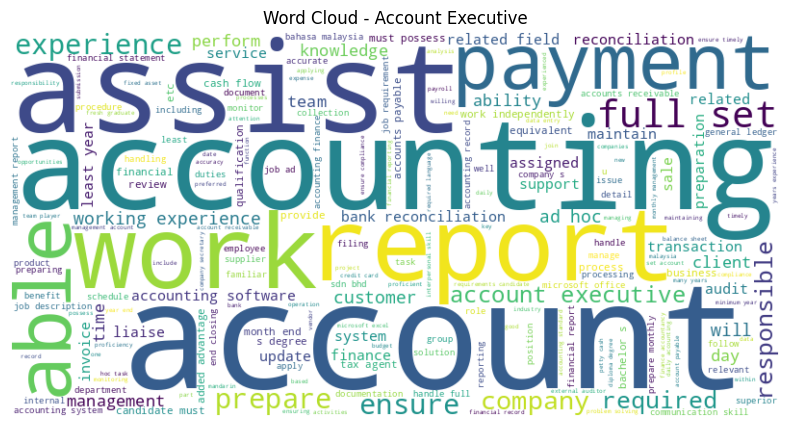

Job Title: Accounts Executive
Jumlah data: 522


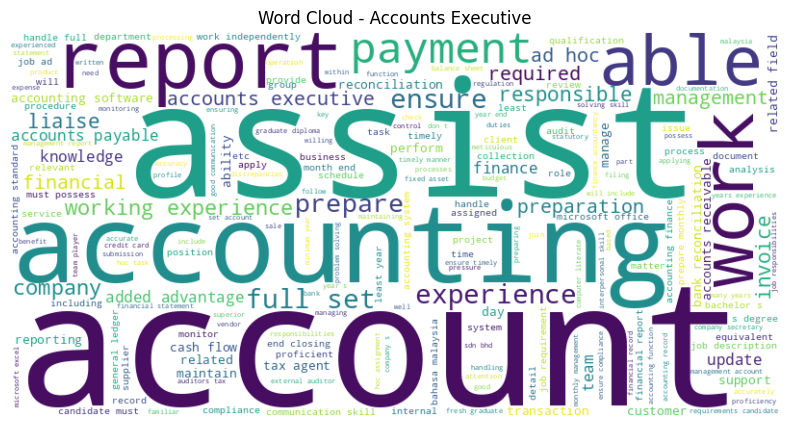

Job Title: Sales Executive
Jumlah data: 466


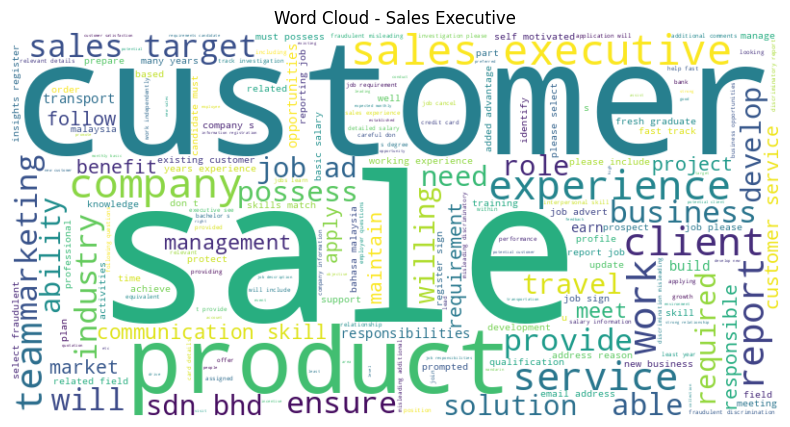

In [ ]:
for title in top_titles:
    subset = df[df["job_title"] == title].copy()
    text = " ".join(subset["description_clean"])

    print("=" * 80)
    print("Job Title:", title)
    print("Jumlah data:", len(subset))

    if text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
        plt.figure(figsize=(12,5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud - {title}")
        plt.show()
    else:
        print("Tidak ada teks yang dapat divisualisasikan untuk Word Cloud.")

Job Title: Account Executive


,term,score
2,accounting,0.286084
3,accounts,0.195622
9,financial,0.182046
1,account,0.163032
10,job,0.160485
18,work,0.159037
5,company,0.152855
7,experience,0.152618
12,monthly,0.139370
11,management,0.136849


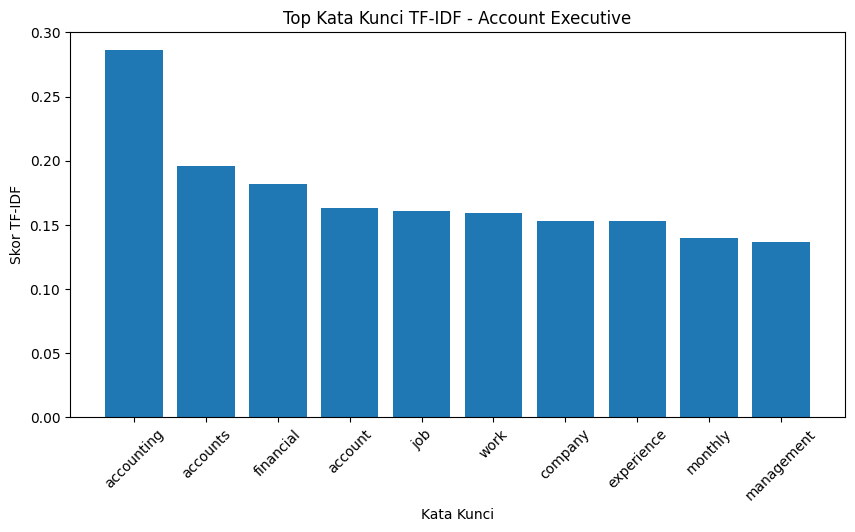

Job Title: Accounts Executive


,term,score
1,accounting,0.298352
2,accounts,0.242313
8,financial,0.186594
18,work,0.167789
9,job,0.163516
6,experience,0.161598
5,ensure,0.158291
4,company,0.155912
17,tax,0.143023
11,monthly,0.142150


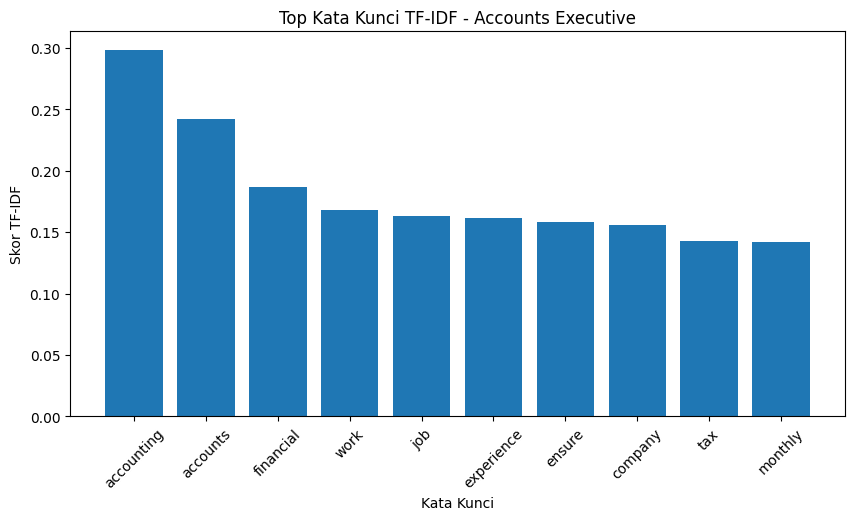

Job Title: Sales Executive


,term,score
16,sales,0.429787
8,job,0.193006
3,customer,0.185981
4,customers,0.164013
2,company,0.152113
0,business,0.150671
6,experience,0.143406
11,new,0.134199
17,skills,0.133600
1,clients,0.130008


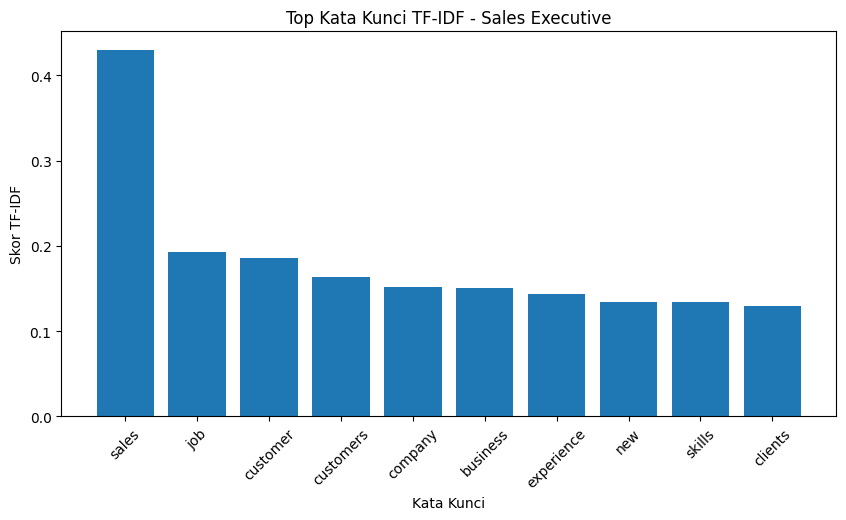

In [ ]:
for title in top_titles:
    subset = df[df["job_title"] == title].copy()

    if len(subset) > 0 and subset["description_clean"].str.strip().any():
        vectorizer = TfidfVectorizer(stop_words="english", max_features=20)
        X = vectorizer.fit_transform(subset["description_clean"])

        terms = vectorizer.get_feature_names_out()
        scores = X.mean(axis=0).A1

        tfidf_df = pd.DataFrame({
            "term": terms,
            "score": scores
        }).sort_values(by="score", ascending=False)

        top_terms = tfidf_df.head(10)

        print("=" * 80)
        print("Job Title:", title)
        display(top_terms)

        plt.figure(figsize=(10,5))
        plt.bar(top_terms["term"], top_terms["score"])
        plt.title(f"Top Kata Kunci TF-IDF - {title}")
        plt.xlabel("Kata Kunci")
        plt.ylabel("Skor TF-IDF")
        plt.xticks(rotation=45)
        plt.show()

### Interpretasi
Word Cloud memberikan gambaran visual mengenai kata-kata yang sering muncul pada deskripsi pekerjaan untuk posisi tertentu. Namun, karena Word Cloud hanya menampilkan frekuensi, analisis ini dilengkapi dengan TF-IDF untuk mengidentifikasi kata yang lebih representatif terhadap suatu job title.

Kata-kata dominan yang ditemukan dapat digunakan untuk memahami karakteristik kompetensi utama pada tiap posisi pekerjaan.

## Evaluasi Kualitas Job Description: Deteksi Data Terlalu Pendek

In [ ]:
short_desc = df[df["desc_word_count"] < 5].copy()
short_desc[["job_title", "description", "desc_word_count"]].head(10)

,job_title,description,desc_word_count
1792,Senior Transportation Planner,New Sidewalks Program Manager,4
3384,Salesforce Developer,𝐒𝐮𝐦𝐦𝐚𝐫𝐲 𝐨𝐟 𝐑𝐨𝐥𝐞\n👤𝐑𝐨𝐥𝐞: 𝐒𝐚𝐥𝐞𝐬𝐟𝐨𝐫𝐜𝐞 𝐃𝐞𝐯𝐞𝐥𝐨𝐩𝐞𝐫💰 ...,1
3968,Group Facilitator,Facilitator,1
4399,Inbound (Stocking) 4AM Team Members,#NAME?,1
5948,Therapist,Licensed,1
5987,Medical Assistant,Apply at lever,3
6000,Robot intern,We will train you!,4
6050,Esthetician,Experience preferred,2
6252,Senior Universal Banker,,0
6763,Sales And Marketing Specialist,internet designer,2


In [ ]:
short_count = len(short_desc)
short_pct = (short_count / len(df)) * 100

print("Jumlah description < 5 kata:", short_count)
print("Persentase:", round(short_pct, 2), "%")

Jumlah description < 5 kata: 84
Persentase: 0.1 %


Text(0, 0.5, 'Jumlah Data')

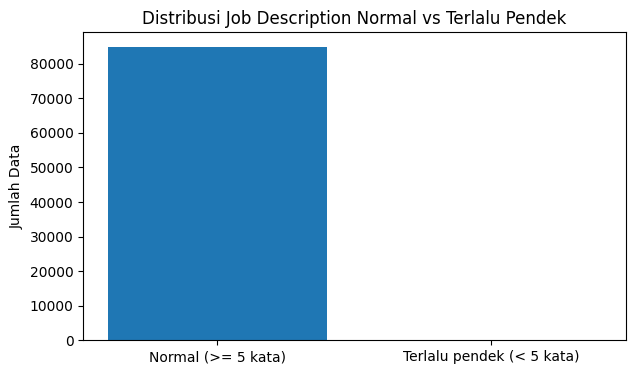

In [ ]:
labels = ["Normal (>= 5 kata)", "Terlalu pendek (< 5 kata)"]
values = [
    len(df[df["desc_word_count"] >= 5]),
    len(df[df["desc_word_count"] < 5])
]

plt.figure(figsize=(7,4))
plt.bar(labels, values)
plt.title("Distribusi Job Description Normal vs Terlalu Pendek")
plt.ylabel("Jumlah Data")

### Interpretasi
Job description yang terlalu pendek cenderung memiliki informasi yang minim dan kurang mampu merepresentasikan kebutuhan pekerjaan secara jelas. Data seperti ini berpotensi menurunkan kualitas analisis berbasis teks, sehingga dapat dipertimbangkan untuk dihapus atau dikecualikan pada tahap lanjutan.

## Explanatory Data Analysis

Berdasarkan hasil exploratory data analysis, dapat disimpulkan bahwa distribusi lowongan kerja tidak merata pada seluruh job title. Beberapa posisi muncul jauh lebih dominan dibandingkan posisi lainnya, yang menunjukkan adanya konsentrasi kebutuhan tenaga kerja pada bidang tertentu.

Dari sisi skill, ditemukan bahwa beberapa keterampilan muncul secara konsisten dalam banyak lowongan kerja. Selain itu, analisis co-occurrence menunjukkan bahwa terdapat pasangan skill tertentu yang sering diminta secara bersamaan, sehingga dapat mencerminkan kombinasi kompetensi yang dianggap penting oleh perusahaan.

Analisis panjang job description menunjukkan bahwa terdapat variasi yang cukup besar dalam jumlah informasi yang disediakan pada tiap lowongan. Sebagian besar lowongan memiliki deskripsi dengan panjang tertentu, tetapi terdapat pula outlier berupa deskripsi yang sangat panjang maupun sangat singkat.

Pada analisis kata kunci dominan per job title, ditemukan bahwa masing-masing posisi memiliki pola kata yang berbeda. Hal ini menunjukkan bahwa teks deskripsi lowongan dapat digunakan sebagai sumber informasi penting untuk membedakan karakteristik antar posisi pekerjaan.

Secara keseluruhan, hasil analisis ini menunjukkan bahwa preprocessing teks, analisis distribusi skill, analisis panjang deskripsi, serta identifikasi kata kunci dominan merupakan langkah penting untuk mendukung tahap feature engineering, text mining, dan pengembangan model pada proyek capstone ini.

## Pemeriksaan Akhir Dataset

Tahap ini dilakukan untuk memastikan dataframe hasil preprocessing dan analisis sudah siap digunakan pada proses lanjutan.

In [ ]:
print("Shape akhir dataframe:", df.shape)
print("\nKolom dataframe:")
print(df.columns)

Shape akhir dataframe: (84910, 11)

Kolom dataframe:
Index(['job_id', 'job_title', 'description', 'location', 'skills',
       'description_clean', 'skills_clean', 'desc_tokens', 'skills_list',
       'skill_count', 'desc_word_count'],
      dtype='object')


In [ ]:
df.head()

,job_id,job_title,description,location,skills,description_clean,skills_clean,desc_tokens,skills_list,skill_count,desc_word_count
0,85008768.0,Licensed Insurance Agent,While many industries were hurt by the last fe...,"Chico, CA",,while many industries were hurt by the last fe...,,"[while, many, industries, were, hurt, by, the,...",[],0,298
1,133114754.0,Sales Manager,Are you a dynamic and creative marketing profe...,"Santa Clarita, CA",,are you a dynamic and creative marketing profe...,,"[are, you, a, dynamic, and, creative, marketin...",[],0,404
2,133196985.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,"New York, NY",,join us as a model risk auditor showcase your ...,,"[join, us, as, a, model, risk, auditor, showca...",[],0,283
3,381055942.0,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,"Forney, TX",,business managerfirst baptist church forneyfor...,,"[business, managerfirst, baptist, church, forn...",[],0,302
4,529257371.0,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,"New York, NY",,you could be one of the magic makers ken fulk ...,,"[you, could, be, one, of, the, magic, makers, ...",[],0,279


## Dataset Siap Analisis Lanjutan

Sebagai langkah opsional, data dengan job description terlalu pendek dapat dihapus untuk menghasilkan dataset yang lebih informatif.

In [ ]:
df_model = df[df["desc_word_count"] >= 5].copy()
print("Shape sebelum filter:", df.shape)
print("Shape sesudah filter:", df_model.shape)

Shape sebelum filter: (84910, 11)
Shape sesudah filter: (84826, 11)
